In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

raw = yf.download("SPY", start="2025-01-01", end="2026-01-01")
data = raw.droplevel("Ticker", axis=1)
data['daily_return'] = data['Close'].pct_change()
sigma = data['daily_return'].std() * np.sqrt(252)
S0 = data['Close'].iloc[-1]
r_free = 0.05
T = 1

print(f"S0: ${S0:.2f}")
print(f"Annual sigma: {sigma:.4f}")

[*********************100%***********************]  1 of 1 completed

S0: $680.06
Annual sigma: 0.1952


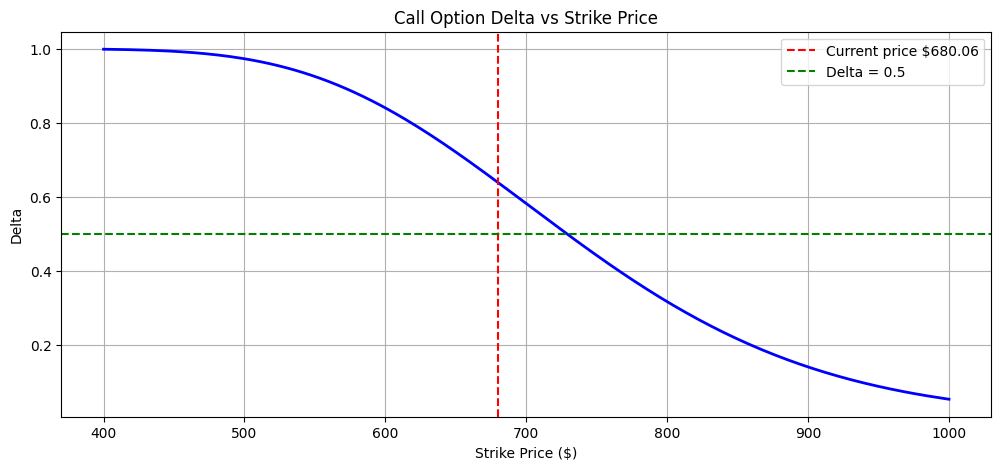

In [5]:
strikes = np.linspace(400, 1000, 200)

#Delta = N(d1)
#Delta range: 0 to 1

#Delta = 0.5  → at the money (strike = current price)
#Delta → 1.0  → deep in the money (strike far below price)
#Delta → 0.0  → deep out of money (strike far above price)

deltas = []
for K in strikes:
    d1 = (np.log(S0/K) + (r_free + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    delta = norm.cdf(d1)
    deltas.append(delta)

deltas = np.array(deltas)

plt.figure(figsize=(12,5))
plt.plot(strikes, deltas, 'b-', linewidth=2)
plt.axvline(x=S0, color='red', linestyle='--', label=f'Current price ${S0:.2f}')
plt.axhline(y=0.5, color='green', linestyle='--', label='Delta = 0.5')
plt.title("Call Option Delta vs Strike Price")
plt.xlabel("Strike Price ($)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

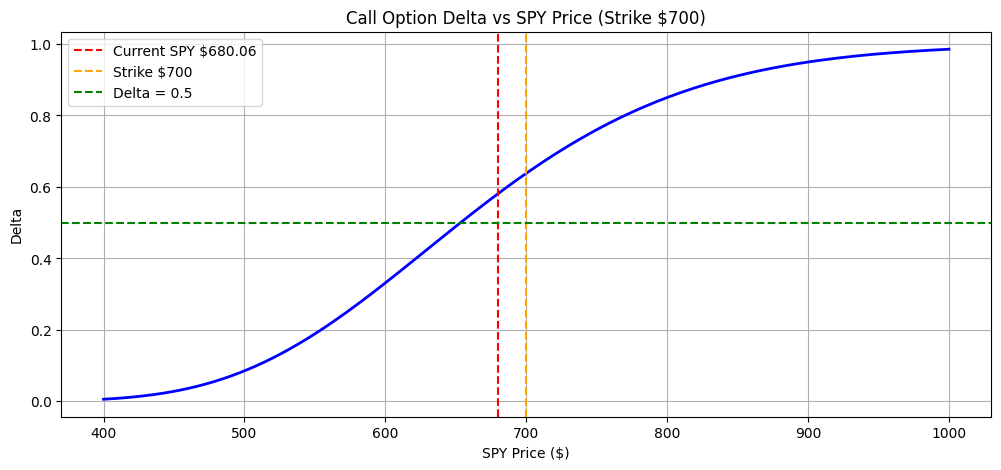

In [11]:
spy_prices = np.linspace(400, 1000, 200)
K = 700

deltas_vs_price = []
for S in spy_prices:
    d1 = (np.log(S/K) + (r_free + 0.5*sigma**2) * T) / (sigma * np.sqrt(T))
    delta = norm.cdf(d1)
    deltas_vs_price.append(delta)

deltas_vs_price = np.array(deltas_vs_price)

plt.figure(figsize=(12,5))
plt.plot(spy_prices, deltas_vs_price, 'b-', linewidth=2)
plt.axvline(x=S0, color='red', linestyle='--', label=f'Current SPY ${S0:.2f}')
plt.axvline(x=K, color='orange', linestyle='--', label=f'Strike ${K}')
plt.axhline(y=0.5, color='green', linestyle='--', label='Delta = 0.5')
plt.title("Call Option Delta vs SPY Price (Strike $700)")
plt.xlabel("SPY Price ($)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()